# Image Classification with TensorFlow

The goal is to recognize the type of a clothing item (T-shirt, trouser, pullover, dress, coat, sandal, shirt, sneaker, bag or ankle boot) from a 28 x 28 pixel grayscale image. The data is Fashion-MNIST: 60,000 training images and 10,000 test images, loaded with Keras (`keras.datasets.fashion_mnist`).

Reference solution: [Image Classification with TensorFlow in Machine Learning](https://amanxai.com/2020/08/30/image-classification-with-tensorflow-in-machine-learning/) (Aman Kharwal), which follows the TensorFlow tutorial for this dataset. The reference trains a network with one hidden layer of 128 neurons for 10 epochs and reports a test accuracy of 0.882. It has no validation set, no result per class and no comparison with another model.

This notebook uses these tools: Keras `Sequential`, `Dense`, convolution layers, `validation_split`, `EarlyStopping`. and compares the reference network with a convolutional network, repeating each training with three random seeds to see how much the result changes from one training to another.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


import os
os.chdir('/mnt/c/Users/myama/OneDrive/Belgeler/ai-1/Assignments/14-Specialize in Data Science/Deep Learning/image_classification_tensorflow')

I0000 00:00:1790326553.513486   65099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790326553.559605   65099 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790326556.885946   65099 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Loading

In [2]:
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
print(train_images.shape, test_images.shape, "| pixel values from", train_images.min(), "to", train_images.max())

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 15us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28) (10000, 28, 28) | pixel values from 0 to 255


## Exploratory Data Analysis

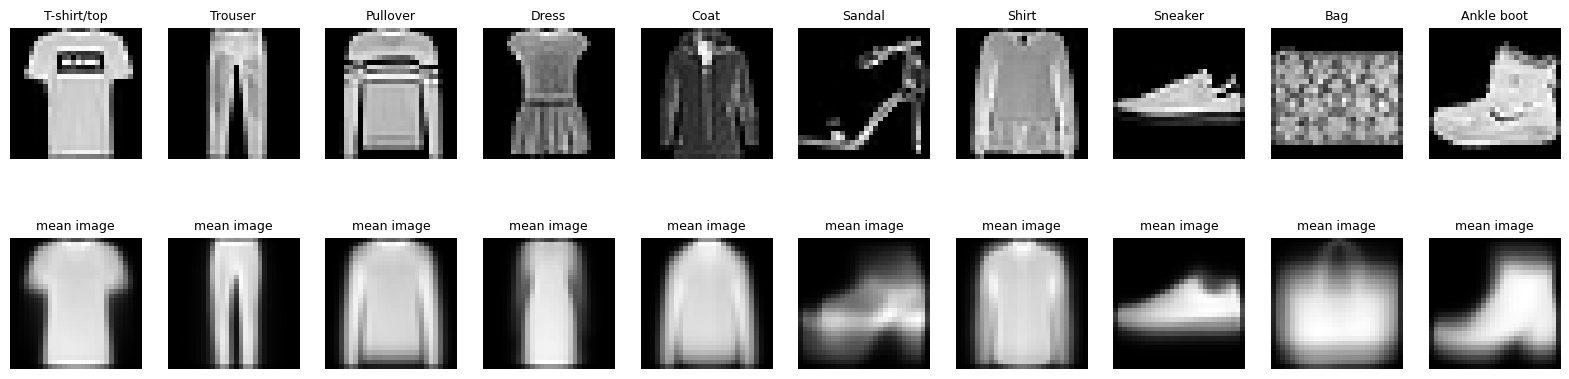

images per class in the training set: [6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000] | in the test set: [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]


In [3]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for label, ax in zip(range(10), axes[0]):
    ax.imshow(train_images[train_labels == label][0], cmap="gray"); ax.set_title(class_names[label], fontsize=9); ax.axis("off")
for label, ax in zip(range(10), axes[1]):
    ax.imshow(train_images[train_labels == label].mean(axis=0), cmap="gray"); ax.set_title("mean image", fontsize=9); ax.axis("off")
plt.show()

print("images per class in the training set:", np.bincount(train_labels).tolist(), "| in the test set:", np.bincount(test_labels).tolist())

The classes are perfectly balanced (6,000 images per class in training, 1,000 in test), so accuracy is a fair metric here and no resampling is needed. The mean images show which classes look alike: the T-shirt, pullover, coat and shirt have similar silhouettes (a body with sleeves), while trousers, sandals, sneakers, bags and boots have distinct shapes. Errors are expected inside the first group.

## Feature Engineering

The pixel values (0 to 255) are divided by 255, as in the reference. The 60,000 training images are used for training (90%) and validation (10%); the 10,000 test images are used only for the final scores. The convolution layers need one channel dimension, which is added to the images.

In [4]:
x_train, x_test = train_images / 255.0, test_images / 255.0
x_train_cnn, x_test_cnn = x_train[..., None], x_test[..., None]

## Model Training

Two networks are compared.

1. **Dense network of the reference:** the image is flattened, one hidden layer of 128 neurons with ReLU, and 10 outputs. It is trained for 10 epochs, as in the reference.
2. **Convolutional network:** two blocks of convolution and max pooling (32 and 64 filters of 3 x 3), a hidden layer of 128 neurons with a dropout of 30%, and 10 outputs. It is trained with early stopping: the training stops when the validation loss has not improved for 3 epochs and the weights of the best epoch are kept.

Each network is trained with three different seeds.

In [5]:
def dense_network():
    model = Sequential([Input(shape=(28, 28)), Flatten(), Dense(128, activation="relu"), Dense(10)])
    model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
    return model

def cnn_network():
    model = Sequential([Input(shape=(28, 28, 1)), Conv2D(32, 3, activation="relu"), MaxPooling2D(), Conv2D(64, 3, activation="relu"), MaxPooling2D(),
                        Flatten(), Dense(128, activation="relu"), Dropout(0.3), Dense(10)])
    model.compile(optimizer="adam", loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=["accuracy"])
    return model

def train(build, x, seed, callbacks=None, epochs=10):
    tf.keras.utils.set_random_seed(seed)
    model = build()
    history = model.fit(x, train_labels, validation_split=0.1, epochs=epochs, batch_size=32, callbacks=callbacks, verbose=0)
    return model, history

runs = {("Dense network (reference)", seed): train(dense_network, x_train, seed) for seed in range(3)}
runs.update({("Convolutional network", seed): train(cnn_network, x_train_cnn, seed, [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)], epochs=30) for seed in range(3)})

I0000 00:00:1790326577.712709   65099 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1790326580.403863   65178 service.cc:153] XLA service 0x768a08030bd0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790326580.403909   65178 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1790326580.461431   65178 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1790326580.582567   65178 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1790326580.591293   65178 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_954__.10
I0000 00:00:1790326582.899941

## Evaluation

In [6]:
def test_scores(name, seed):
    model, history = runs[(name, seed)]
    inputs = x_test_cnn if "Convolutional" in name else x_test
    prediction = model.predict(inputs, verbose=0).argmax(axis=1)
    return {"test accuracy": accuracy_score(test_labels, prediction), "epochs": len(history.history["loss"]),
            "parameters": model.count_params(), "training accuracy": history.history["accuracy"][-1], "validation accuracy": history.history["val_accuracy"][-1]}

results = pd.DataFrame({key: test_scores(*key) for key in runs}).T
results.groupby(level=0).agg(["mean", "std"]).round(4)

test accuracy           epochs         parameters  \
                                   mean     std     mean     std       mean   
Convolutional network            0.9047  0.0048   9.3333  0.5774   225034.0   
Dense network (reference)        0.8761  0.0010  10.0000  0.0000   101770.0   

                               training accuracy         validation accuracy  \
                           std              mean     std                mean   
Convolutional network      0.0            0.9371  0.0056              0.9142   
Dense network (reference)  0.0            0.9140  0.0012              0.8795   

                                   
                              std  
Convolutional network      0.0048  
Dense network (reference)  0.0038

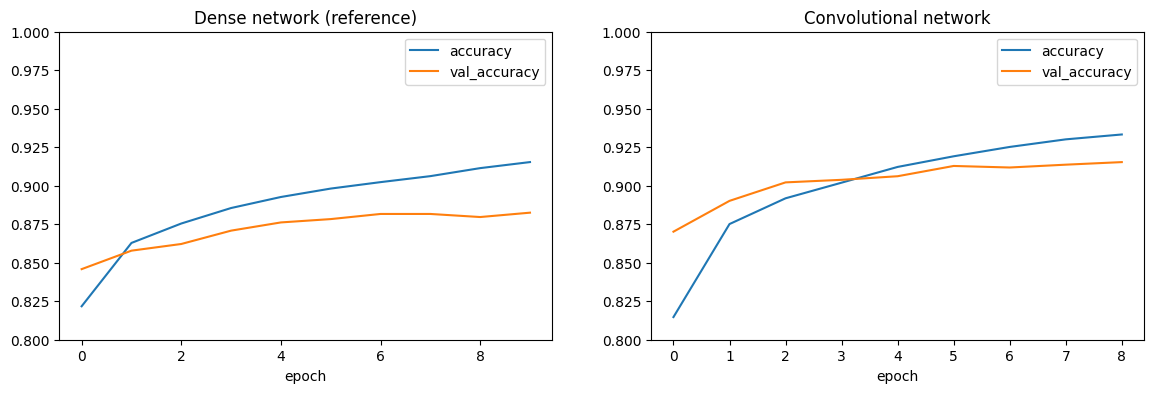

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, name in zip(axes, ["Dense network (reference)", "Convolutional network"]):
    pd.DataFrame(runs[(name, 0)][1].history)[["accuracy", "val_accuracy"]].plot(ax=ax, title=name, ylim=(0.8, 1.0), xlabel="epoch")
plt.show()

The reference network reaches 0.875 on the test set on average over three seeds (the reference reports 0.882 for one training, which is inside the range of one seed). It fits the training data better (0.915) than the validation data (0.883), so it already overfits a little after 10 epochs. The convolutional network is better on all sets: 0.906 on the test set, against 0.875. The difference between the two networks (0.031) is more than ten times the standard deviation between seeds (0.002 to 0.003), so it is not a matter of a lucky initialization. The price is about twice as many parameters (225,034 against 101,770) and a slower training. The convolution layers look at small neighbourhoods of pixels and reuse the same filter at every position, which suits images better than a flattened vector where the network must learn the position of every edge separately.

## Errors per Class

The classification report and the confusion matrix of the convolutional network (seed 0) show where the errors are, which the single accuracy of the reference does not.

              precision    recall  f1-score   support

 T-shirt/top      0.888     0.797     0.840      1000
     Trouser      0.990     0.981     0.985      1000
    Pullover      0.853     0.838     0.846      1000
       Dress      0.860     0.941     0.899      1000
        Coat      0.827     0.872     0.849      1000
      Sandal      0.977     0.984     0.981      1000
       Shirt      0.729     0.716     0.723      1000
     Sneaker      0.953     0.967     0.960      1000
         Bag      0.982     0.972     0.977      1000
  Ankle boot      0.972     0.958     0.965      1000

    accuracy                          0.903     10000
   macro avg      0.903     0.903     0.902     10000
weighted avg      0.903     0.903     0.902     10000



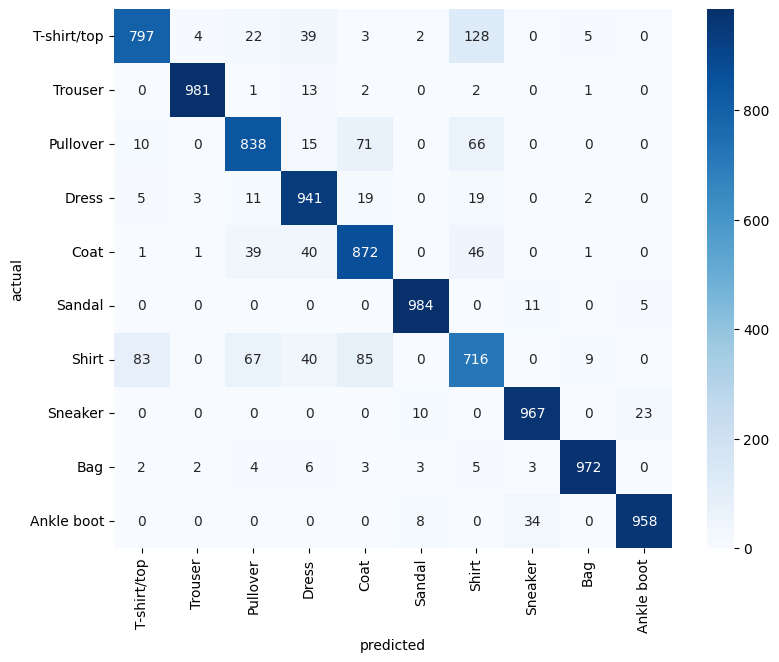

T-shirt/top  Shirt          128
Shirt        Coat            85
             T-shirt/top     83
Pullover     Coat            71
Shirt        Pullover        67
dtype: int64

In [8]:
cnn, _ = runs[("Convolutional network", 0)]
prediction = cnn.predict(x_test_cnn, verbose=0).argmax(axis=1)

print(classification_report(test_labels, prediction, target_names=class_names, digits=3))
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(test_labels, prediction), annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("predicted"); plt.ylabel("actual"); plt.show()

confusions = pd.DataFrame(confusion_matrix(test_labels, prediction), index=class_names, columns=class_names).stack()
confusions[confusions.index.get_level_values(0) != confusions.index.get_level_values(1)].sort_values(ascending=False).head(5)

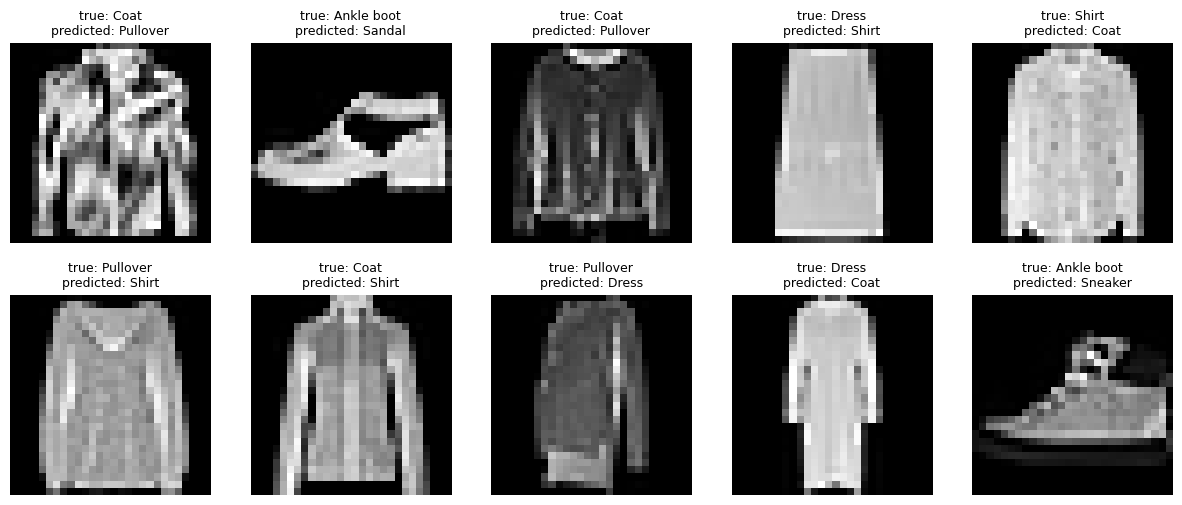

In [9]:
wrong = np.where(prediction != test_labels)[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, i in zip(axes.ravel(), wrong):
    ax.imshow(test_images[i], cmap="gray"); ax.set_title(f"true: {class_names[test_labels[i]]}\npredicted: {class_names[prediction[i]]}", fontsize=9); ax.axis("off")
plt.show()

The single accuracy hides large differences between the classes. Trousers, sandals, sneakers, bags and ankle boots have an F1 score above 0.96. The four upper-body classes are the weak part: the shirt has the lowest recall (0.630) and F1 (0.700); 126 shirts are predicted as T-shirts, 102 as coats and 89 as pullovers. Coat and pullover are also confused with each other (64 coats predicted as pullovers). A 28 x 28 grayscale image often does not show the collar, the buttons or the length of the sleeves, which are the only differences between these classes. To improve the score, the effort should go to these classes (more data, a deeper network, augmentation), because the other six are already nearly solved.

## Conclusion

- The dense network of the reference (test accuracy 0.875 over three seeds) is a reasonable baseline but it overfits slightly and it is reported without a validation set or a per-class result.
- A small convolutional network improves the test accuracy to 0.906. The gain is much larger than the variation between seeds, so it is real.
- The remaining errors are concentrated in shirt, T-shirt, pullover and coat. The shirt class alone has an F1 score of 0.70, while six classes are above 0.96.
- Differences from the reference: three seeds per model instead of one training, a validation split with early stopping, a classification report and a confusion matrix, and a comparison with a second architecture.
- Limitation: the test set was used only for the final scores, but the architecture of the convolutional network was chosen once and not tuned; a tuned or deeper network could probably do better.